# PoI-accessibility

El presente *notebook* implementa la métrica PoI-accessibility, presentada por
[Mirko Lai et. al. (2026)](https://doi.org/10.1371/journal.pone.0342156). Esta
métrica, contraria a las demás que se han analizado durante el proyecto, no
obtiene un índice ponderando la accesibilidad individual para cada necesidad,
sino que pondera tres índices (PoI-proximity, PoI-density y PoI-entropy) que
consideran todas las necesidades al mismo tiempo.

Se consideran como necesidades las farmacias, supermercados, parques, plazas y
hospitales/clínicas.

In [1]:
%reload_ext autoreload
%autoreload 2

In [33]:
import datetime
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import xmin
from xmin.dataset import extract_osm_subset

tqdm.pandas()

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures")
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [4]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_SALUD_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
AMENITY_VERDES_PATH = PRE_DATA_PATH / "amenities" / "areas_verdes.gpkg"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago.osm.pbf"

## Orígenes, destinos y TTMs

In [5]:
# carga de datos
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24",
)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN SANTIAGO")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

In [6]:
manzanas = gpd.read_file(
    CENSO_PATH,
    layer="Manzanas_CPV24",
    mask=limites_urbanos.union_all(),
    use_arrow=True
)

In [7]:
origins = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=9,
    population_gdf=manzanas.rename(columns={"n_per": "population"}),
)

In [8]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=limites_envoltura
    )

In [9]:
farmacias = xmin.Amenity.from_osm(
    name="farmacias",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
    keep_all_tags=["name"]
)

In [10]:
supermercados = xmin.Amenity.from_osm(
    name="supermercados",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"shop": ["supermarket"]},
    keep_all_tags=["name"]
)

In [11]:
salud_gdf = gpd.read_file(AMENITY_SALUD_PATH, mask=limites_envoltura)

salud = xmin.Amenity(
    name="salud",
    amenity_gdf=salud_gdf[salud_gdf["TIPO"].isin(["Hospital", "Clínica"])]
)

In [12]:
verdes_gdf = gpd.read_file(
    AMENITY_VERDES_PATH, layer="puntos", mask=limites_envoltura
)

parques = xmin.Amenity(
    name="parques", amenity_gdf=verdes_gdf[verdes_gdf["TIPO_EP"] == "PARQUE"]
)
plazas = xmin.Amenity(
    name="plazas", amenity_gdf=verdes_gdf[verdes_gdf["TIPO_EP"] == "PLAZA"]
)

In [13]:
ttms = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[farmacias, supermercados, salud, plazas, parques],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=60),
    transport_modes=["WALK"],
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

In [14]:
# agrupamos parques y plazas, para que no cuente cada entrada como un destino
# completamente distinto
ttms.group_amenity_destinations("parques", "park_id")
ttms.group_amenity_destinations("plazas", "park_id")

## Definición de nuevo rating

Creamos las funciones para calcular PoI-proximity, PoI-density y PoI-entropy
para cada origen, según se definen en el paper de Lai et. al.

In [15]:
def poi_proximity(travel_times: pd.DataFrame) -> pd.Series:
    """
    Calcula PoI-proximity para un origen, según los tiempos de viaje a los
    destinos de distintas necesidades.
    
    El índice se define como el menor tiempo de viaje necesario para poder
    acceder a al menos un destino por cada necesidad. Si no se puede acceder a
    ningún destino para alguna necesidad, el rating obtenido es NaN.
    """

    min_time_by_amenity = travel_times.groupby("_amenity_id")[
        "travel_time"
    ].min()

    return min_time_by_amenity.max(skipna=False)

Para PoI-density, no tenemos acceso a las isócronas desde cada origen, por lo
cual en vez de usar la razón entre la cantidad de destinos y el área de la
isócrona, simplemente usamos la cantidad de destinos.

In [16]:
def poi_density(travel_times: pd.DataFrame, threshold: float) -> pd.Series:
    """
    Calcula PoI-density para un origen, según los tiempos de viaje a los
    destinos de distintas necesidades.
    
    El índice se define como la cantidad total de destinos que se pueden
    alcanzar en un tiempo de viaje menor a `threshold`, sin importar la
    categoría a la cual pertenezcan.
    """

    return travel_times[travel_times["travel_time"] <= threshold][
        "travel_time"
    ].count()

In [17]:
def poi_entropy(travel_times: pd.DataFrame, threshold: float) -> pd.Series:
    """
    Calcula PoI-entropy para un origen, según los tiempos de viaje a los
    destinos de distintas necesidades.

    El índice se define como la sumatoria de `(Pr(A) * log Pr(A))` para cada
    Amenity `A`, donde `Pr(A)` es la tasa de destinos que pertenecen a `A`
    entre todos los que tienen tiempo de viaje menor a `threshold`.
    """

    counts = travel_times[travel_times["travel_time"] <= threshold][
        "_amenity_id"
    ].value_counts()

    probs = counts / counts.sum()

    return -(probs * np.log(probs)).sum()

In [18]:
def normalize(
    values: pd.Series, best_value: float, worst_value: float
) -> pd.Series:
    """
    Normaliza valores de una serie `values`, para que `best_value` sea 1,
    `worst_value` sea 0, valores intermedios sean convertidos linealmente al
    rango (0, 1), y valores fuera del rango sean clippeados a 0 o 1.
    `best_value` puede ser mayor o menor que `worst_value`.
    """
    
    return ((values - worst_value) / (best_value - worst_value)).clip(0, 1)

Para calcular el índice completo (retornando el objeto `AccessibilityRatings`
correspondiente), no usamos `AccessibilityRatings.compute()` (ya que ese método
considera un índice independiente para cada necesidad), sino que creamos una
función que calcula el índice, crea el GeoDataFrame con los ratings (proximity,
density, entropy y el ponderado) y retorna el objeto apropiado.

In [19]:
def compute_poi_accessibility(
    travel_time_matrices: xmin.TravelTimeMatrices,
    proximity_best_time: float | None = None,
    proximity_worst_time: float | None = None,
    density_threshold: float = 15,
    density_best_value: float | None = None,
    density_worst_value: float | None = None,
    entropy_threshold: float = 15,
    entropy_best_value: float | None = None,
    entropy_worst_value: float | None = None,
    proximity_weight: float = 1,
    density_weight: float = 1,
    entropy_weight: float = 1,
) -> xmin.AccessibilityRatings:
    """
    Calcula el índice PoI-accessibility.

    Parameters
    ---
    travel_time_matrices : TravelTimeMatrices
        Matrices de tiempo de viaje que se desean utilizar para construir los
        ratings de accesibilidad.
    proximity_best_time : float or None, default: None
        Tiempo de PoI-proximity para el cual se asigna un puntaje del 100%. Si
        es None, se utiliza el menor tiempo obtenido.
    proximity_worst_time : float or None, default: None
        Tiempo de PoI-proximity para el cual se asigna un puntaje del 0%. Si es
        None, se utiliza el mayor tiempo obtenido.
    density_threshold : float, default: 15
        Tiempo límite a utilizar en el cálculo de PoI-density.
    density_best_value : float or None, default: None
        Valor de PoI-density para el cual se asigna un puntaje del 100%. Si es
        None, se utiliza el mayor puntaje obtenido.
    density_worst_value : float or None, default: None
        Valor de PoI-density para el cual se asigna un puntaje del 0%. Si es
        None, se utiliza el menor puntaje obtenido.
    entropy_threshold : float, default: 15
        Tiempo límite a utilizar en el cálculo de PoI-entropy.
    entropy_best_value : float or None, default: None
        Valor de PoI-entropy para el cual se asigna un puntaje del 100%. Si es
        None, se utiliza el mayor puntaje obtenido.
    entropy_worst_value : float or None, default: None
        Valor de PoI-entropy para el cual se asigna un puntaje del 0%. Si es
        None, se utiliza el menor puntaje obtenido.
    proximity_weight : float, default: 1
        Peso relativo de PoI-proximity en el cálculo de PoI-accessibility
        (índice ponderado).
    density_weight : float, default: 1
        Peso relativo de PoI-density en el cálculo de PoI-accessibility (índice
        ponderado).
    entropy_weight : float, default: 1
        Peso relativo de PoI-entropy en el cálculo de PoI-accessibility (índice
        ponderado).

    Returns
    ---
    Objeto `AccessibilityRatings` con las puntuaciones para cada métrica. La
    columna `"total"` guarda el índice ponderado (PoI-accessibility).
    """

    # add dummy dataframes, with one NaN travel time from each origin to each
    # amenity, so that every origin-amenity pair has at least one row and all
    # calculations are performed correctly (even if the TTMs were calculated
    # with dropna=True)
    ttms_to_combine = []
    for name, ttm in travel_time_matrices.matrices.items():
        ttms_to_combine.append(ttm.assign(_amenity_id=name))
        ttms_to_combine.append(
            pd.DataFrame(
                {
                    "from_id": travel_time_matrices.origins.h3_grid["id"],
                    "to_id": "dummy",
                    "travel_time": np.nan,
                    "_amenity_id": name,
                }
            )
        )
    combined_ttm = pd.concat(ttms_to_combine, ignore_index=True)

    grouped_origins = combined_ttm.set_index("to_id").groupby("from_id")[
        ["travel_time", "_amenity_id"]
    ]

    print("Calculando PoI-proximity...")
    unclipped_proximity = grouped_origins.progress_apply(poi_proximity)
    print("Calculando PoI-density...")
    unclipped_density = grouped_origins.progress_apply(
        lambda df: poi_density(df, threshold=density_threshold)
    )
    print("Calculando PoI-entropy...")
    unclipped_entropy = grouped_origins.progress_apply(
        lambda df: poi_entropy(df, threshold=entropy_threshold)
    )

    if proximity_best_time is None:
        proximity_best_time = unclipped_proximity.min()
    if proximity_worst_time is None:
        proximity_worst_time = unclipped_proximity.max()
    if density_best_value is None:
        density_best_value = unclipped_density.max()
    if density_worst_value is None:
        density_worst_value = unclipped_density.min()
    if entropy_best_value is None:
        entropy_best_value = unclipped_entropy.max()
    if entropy_worst_value is None:
        entropy_worst_value = unclipped_entropy.min()

    proximity = normalize(
        unclipped_proximity,
        proximity_best_time,
        proximity_worst_time,
    ).fillna(0)
    density = normalize(
        unclipped_density,
        density_best_value,
        density_worst_value,
    ).fillna(0)
    entropy = normalize(
        unclipped_entropy,
        entropy_best_value,
        entropy_worst_value,
    ).fillna(0)

    origins = travel_time_matrices.origins
    amenities = travel_time_matrices.amenities.values()
    weights = {
        "proximity": proximity_weight,
        "density": density_weight,
        "entropy": entropy_weight,
    }
    gdf = gpd.GeoDataFrame(
        {
            "proximity": proximity,
            "density": density,
            "entropy": entropy,
            "total": (
                proximity * proximity_weight
                + density * density_weight
                + entropy * entropy_weight
            )
            / (proximity_weight + density_weight + entropy_weight),
        },
        geometry=origins.h3_grid.set_index("id")["geometry"],
        index=origins.h3_grid["id"],
        crs=4326,
    )

    return xmin.AccessibilityRatings(origins, amenities, weights, gdf)

In [20]:
acc = compute_poi_accessibility(ttms)

Calculando PoI-proximity...


  0%|          | 0/9025 [00:00<?, ?it/s]

Calculando PoI-density...


  0%|          | 0/9025 [00:00<?, ?it/s]

Calculando PoI-entropy...


  0%|          | 0/9025 [00:00<?, ?it/s]

## Visualización

Al visualizar cada métrica por separado, notamos como cada una considera un
aspecto distinto del concepto de "accesibilidad". Las zonas con mayor
proximidad se encuentran en Santiago Centro y el eje Providencia, con algunos
clusters importantes en comunas más periféricas (p. ej. Maipú, donde se
encuentra la celda con mejor puntuación). La zona de mayor densidad se
encuentra con diferencia en Santiago Centro, pero es interesante notar que esa
misma zona no tiene una puntuación particularmente alta para PoI-entropy; esto
demuestra que esa zona tiene muchos destinos, pero la gran mayoría
pertenecientes a una sola categoría (farmacias, en este caso). La entropía
tiene una distribución menos concentrada, existiendo múltiples lugares en
Santiago con valores elevados.

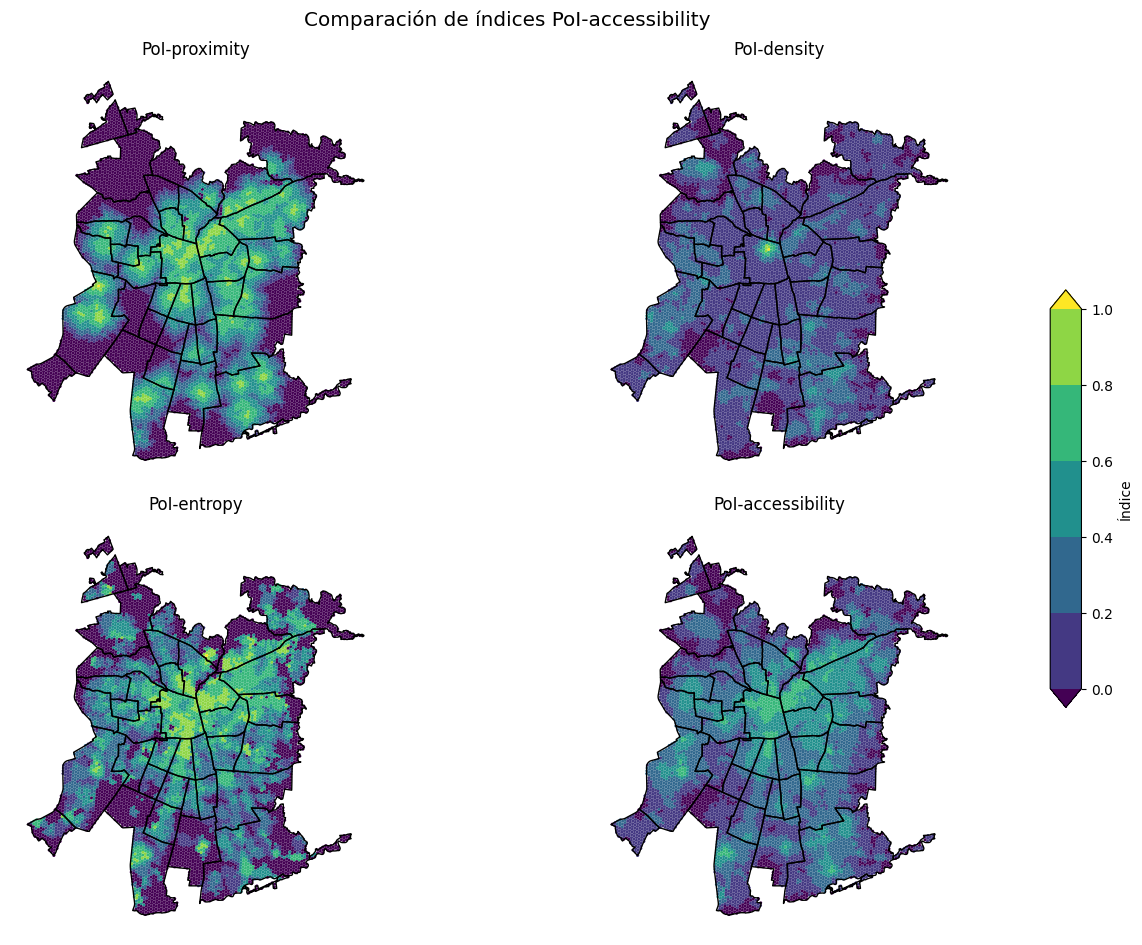

In [27]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_proximity = fig.add_subplot(gs[0:2, 0])
ax_density = fig.add_subplot(gs[0:2, 1])
ax_entropy = fig.add_subplot(gs[2:4, 0])
ax_total = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

norm = mcolors.BoundaryNorm(
    [1e-10, 0.2, 0.4, 0.6, 0.8, 1.0], ncolors=256, extend="both"
)

for ax, category, name in zip(
    (ax_proximity, ax_density, ax_entropy, ax_total),
    ("proximity", "density", "entropy", "total"),
    ("PoI-proximity", "PoI-density", "PoI-entropy", "PoI-accessibility")
):
    acc.visualize.choropleth(category, ax=ax, norm=norm)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Índice")

fig.suptitle("Comparación de índices PoI-accessibility", fontsize="x-large")

plt.tight_layout()
plt.savefig(IMG_PATH / "poi_accessibility.pdf")

In [24]:
best_density_cell = acc.gdf.loc[[acc.gdf["density"].idxmax()]]
cropped_acc = acc.crop(best_density_cell)

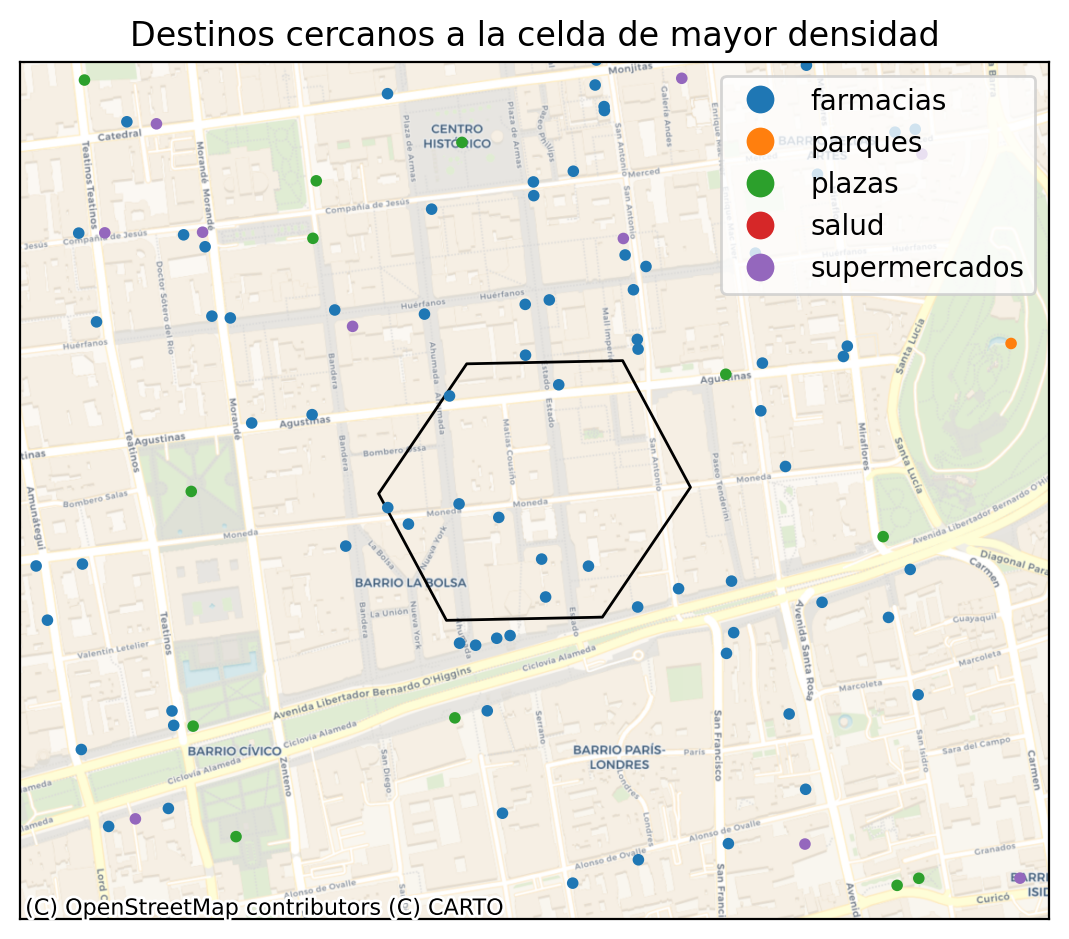

In [48]:
fig, ax = plt.subplots(dpi=200)

# empty plot (just to get limits)
cropped_acc.visualize.choropleth(
    "density",
    ax=ax,
    alpha=0,
    overlay_cfg=xmin.OverlayConfig(show_borders=False),
)

# expand limits
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
ax.set_xlim((x0 - (x1 - x0), x1 + (x1 - x0)))
ax.set_ylim((y0 - (y1 - y0), y1 + (y1 - y0)))

# actual plot
cmap = mpl.colormaps.get_cmap("tab10")
colors = [cmap(i) for i in range(len(cropped_acc.amenities))]
cmap = mcolors.ListedColormap(colors)
cropped_acc.visualize.choropleth(
    "density",
    ax=ax,
    alpha=0,
    overlay_cfg=xmin.OverlayConfig(
        show_amenities=True,
        show_basemap=True,
        amenities_kwds={"cmap": cmap, "markersize": 10},
        basemap_kwds={"zoom": 17},
    ),
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Destinos cercanos a la celda de mayor densidad")

plt.tight_layout()
plt.savefig(IMG_PATH / "poi_accessibility_zoom.pdf")